In [2]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
from datetime import datetime
import csv
import json
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from jpeg_aug import RandomJPEGCompression

In [3]:
# Checking Device/confirming it works with CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [ ]:
# Helper Functions

def subset_dataset(dataset, percent, seed=6050):
    if percent >= 1.0:
        return dataset
    
    random.seed(seed)
    subset_size = int(len(dataset) * percent)
    indices = random.sample(range(len(dataset)), subset_size)
    return Subset(dataset, indices)

def plot_loss_and_acc(track_loss, track_train_acc, track_val_acc):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(track_train_acc, label="Train")
    plt.plot(track_val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(track_loss, label="Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def get_dataset_records(dataset, split_name):
    """
    Returns: list of dicts: {image_path, image_type, image_split}
    Works for both ImageFolder and Subset.
    """

    records = []

    # Determine base dataset (ImageFolder) and indices
    if isinstance(dataset, torch.utils.data.Subset):
        base = dataset.dataset
        indices = dataset.indices
    else:
        base = dataset
        indices = range(len(dataset))

    # Reverse mapping: 0→Real, 1→Fake
    label_map = {0: "real", 1: "fake"}

    # Collect rows
    for idx in indices:
        path, label = base.samples[idx]  # (full_path, original_label)

        # Apply label swap: real=0, fake=1
        correct_label = 1 - label
        label_name = label_map[correct_label]

        # Keep last 3 parts of path
        short_path = "/".join(Path(path).parts[-3:])

        records.append({
            "image_path": short_path,
            "image_type": label_name,
            "image_split": split_name
        })

    return records

def create_run_logger(model_name, params, timestamp, log_dir="logs"):
    os.makedirs(log_dir, exist_ok=True)

    # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Create file paths
    log_txt = os.path.join(log_dir, f"{model_name}_run_{timestamp}.txt")
    log_json = os.path.join(log_dir, f"{model_name}_run_{timestamp}.json")

    # Initialize JSON log structure
    json_log = {
        "timestamp": timestamp,
        "model": model_name,
        "parameters": params,
        "epoch_data": []
    }

    # Write initial text header
    with open(log_txt, "w") as f:
        f.write("TRAINING RUN START \n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Model: {model_name}\n")
        f.write("\nPARAMETERS \n")
        for k, v in params.items():
            f.write(f"{k}: {v}\n")
        f.write("\n==============================\n\n")

    return log_txt, log_json, json_log

def loading_data(train_dir, val_dir, transform, train_ratio = 1.0, batch_size=32, num_workers=0):

    train_dataset = CustomImageFolder(root=str(train_dir), transform=transform)
    val_dataset = CustomImageFolder(root=str(val_dir), transform=transform)

    print("Original class mapping:", train_dataset.class_to_idx)  # still 'fake':0, 'real':1

    if train_ratio >= 1.0 or train_ratio <= 0.0:
        print("Using all the data")
    else:
        train_dataset = subset_dataset(train_dataset, train_ratio)
        val_dataset = subset_dataset(val_dataset, train_ratio)
        print(f"Using {train_ratio*100}% of the data")

    #DATALOADERS
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    print(f"Training on {len(train_dataset)} images, validating on {len(val_dataset)} images.")

    # logging data splits
    train_records = get_dataset_records(train_dataset, "train")
    val_records = get_dataset_records(val_dataset, "validation")

    all_records = train_records + val_records

    csv_datetime = datetime.now().strftime('%Y%m%d_%H%M%S')
    csv_name = f"dataset_split_{csv_datetime}.csv"
    csv_path = f"logs/{csv_name}"

    os.makedirs("logs", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["image_path", "image_type", "image_split"])
        writer.writeheader()
        writer.writerows(all_records)

    print(f"Saved dataset split CSV to: {csv_path}")
    print(f"Total records: {len(all_records)}")

    return train_loader, val_loader, train_dataset, val_dataset, csv_name

def make_loader_for_windows(dataset, real_indices, fake_indices_by_w, 
                            windows, batch_size, shuffle, num_workers=0):
    all_indices = list(real_indices)
    for w in windows:
        all_indices.extend(fake_indices_by_w[w])
    subset = Subset(dataset, all_indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
    return loader, len(all_indices)

def create_run_logger(model_name, params, timestamp, log_dir="logs"):
    os.makedirs(log_dir, exist_ok=True)

    # Log file paths
    log_txt = os.path.join(log_dir, f"{model_name}_run_{timestamp}.txt")
    log_json = os.path.join(log_dir, f"{model_name}_run_{timestamp}.json")

    # JSON structure
    json_log = {
        "timestamp": timestamp,
        "model": model_name,
        "parameters": params,
        "steps": []   # < sliding steps
    }

    # TXT file
    with open(log_txt, "w") as f:
        f.write("TRAINING RUN START\n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Model: {model_name}\n\n")
        f.write("PARAMETERS:\n")
        for k, v in params.items():
            f.write(f"  {k}: {v}\n")
        f.write("\n==============================\n\n")

    return log_txt, log_json, json_log

def logger_add_step(json_log, step_index, windows_used):
    step_entry = {
        "step": step_index,
        "windows_used": windows_used,
        "epochs": []   # epochs get appended inside this
    }
    json_log["steps"].append(step_entry)

def logger_add_epoch(json_log, step_index, epoch_index, metrics):
    """
    metrics = {
        "train_loss": ...,
        "train_acc": ...,
        "val_past_acc": ...,
        "val_next_acc": ...,
        "val_all_acc": ...,
        "epoch_minutes": ...
    }
    """
    json_log["steps"][step_index]["epochs"].append({
        "epoch": epoch_index,
        **metrics
    })

def save_json_log(json_log, json_path):
    with open(json_path, "w") as f:
        json.dump(json_log, f, indent=4)

# dataloader loads alphabetically, so we need to swap labels
class CustomImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        # Swap label: make 'real' = 0, 'fake' = 1
        label = 1 - label
        return img, label

In [ ]:
# CONFIGURATION

data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")  # adjust as needed
train_dir = data_root / "train"
val_dir = data_root / "validation"

batch_size = 32
num_workers = 4
num_epochs = 5
learning_rate = 1e-4
train_percent = 1.0  # train/validate on 50% of data

In [6]:
# DATA TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize for ResNet
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    RandomJPEGCompression(quality_range=(30, 95)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

'''
resize will resize the image to 256x256
randomcrop will random crop a 224x224 image from the 256x256 image
randomhorizontalflip will randomly flip the image horizontally

toTensor will convert the image to a tensor
normalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on

'''

'\nresize will resize the image to 256x256\nrandomcrop will random crop a 224x224 image from the 256x256 image\nrandomhorizontalflip will randomly flip the image horizontally\n\ntoTensor will convert the image to a tensor\nnormalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on\n\n'

In [ ]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = loading_data(train_dir, 
                                                                    val_dir, 
                                                                    transform, 
                                                                    train_ratio = train_percent,
                                                                    batch_size=batch_size, 
                                                                    num_workers=0)

Original class mapping: {'fake': 0, 'real': 1}
Using 20.0% of the data
Training on 23040 images, validating on 5668 images.
Saved dataset split CSV to: logs/dataset_split_20251130_083358.csv
Total records: 28708


In [8]:
# Paths to your fake CSVs (adjust names/paths as needed) ---
train_fake_csv_path = r'C:/Users/Jimmy/OneDrive/Desktop/ID_of_AI_Images/temporal_validation/fake_train_temporal_splits.csv'
val_fake_csv_path = r'C:/Users/Jimmy/OneDrive/Desktop/ID_of_AI_Images/temporal_validation/fake_validation_temporal_splits.csv'

train_fake_df = pd.read_csv(train_fake_csv_path)
val_fake_df = pd.read_csv(val_fake_csv_path)

# Ensure filename column is just the basename (in case it has paths)
train_fake_df["filename"] = train_fake_df["filename"].apply(os.path.basename)
val_fake_df["filename"] = val_fake_df["filename"].apply(os.path.basename)

# Map: filename -> window
train_file_to_window = dict(zip(train_fake_df["filename"], train_fake_df["w_split"]))
val_file_to_window = dict(zip(val_fake_df["filename"],   val_fake_df["w_split"]))

# Determine max window index
max_train_w = train_fake_df["w_split"].max()
max_val_w = val_fake_df["w_split"].max()
max_w = int(max(max_train_w, max_val_w))

print(f"Max window index detected: {max_w}")

Max window index detected: 8


In [10]:
# Handle Subset and Full Dataset
def get_base_dataset(ds):
    """Return (base_dataset, indices_list) whether ds is Subset or full dataset."""
    if isinstance(ds, torch.utils.data.Subset):
        return ds.dataset, ds.indices
    else:
        return ds, list(range(len(ds)))

base_train_ds, train_indices = get_base_dataset(train_dataset)
base_val_ds, val_indices   = get_base_dataset(val_dataset)

FAKE_CLASS = base_train_ds.class_to_idx["fake"]  # flipped: fake=0, real=1
REAL_CLASS = base_train_ds.class_to_idx["real"]

# Create mapping: index_in_train_dataset → actual_path_and_class
train_samples = base_train_ds.samples
val_samples   = base_val_ds.samples

# Determine max window
max_train_w = train_fake_df["w_split"].max()
max_val_w = val_fake_df["w_split"].max()
max_w = int(max(max_train_w, max_val_w))

# Storage structures
train_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
val_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
train_real_indices = []
val_real_indices = []

# Build TRAIN indices properly whether subset or not
for new_i, original_i in enumerate(train_indices):
    path, cls = train_samples[original_i]
    fname = os.path.basename(path)

    if cls == REAL_CLASS:
        train_real_indices.append(new_i)

    elif cls == FAKE_CLASS:
        if fname in train_file_to_window:
            w = int(train_file_to_window[fname])
            train_fake_indices_by_w[w].append(new_i)
        else:
            print(f"[WARN] Train fake missing from CSV: {fname}")

# Build VAL indices properly
for new_i, original_i in enumerate(val_indices):
    path, cls = val_samples[original_i]
    fname = os.path.basename(path)

    if cls == REAL_CLASS:
        val_real_indices.append(new_i)

    elif cls == FAKE_CLASS:
        if fname in val_file_to_window:
            w = int(val_file_to_window[fname])
            val_fake_indices_by_w[w].append(new_i)
        else:
            print(f"[WARN] Val fake missing from CSV: {fname}")

print("Train real:", len(train_real_indices))
for w in range(max_w + 1):
    print(f"Train fake w{w}: {len(train_fake_indices_by_w[w])}")

print("Val real:", len(val_real_indices))
for w in range(max_w + 1):
    print(f"Val fake w{w}: {len(val_fake_indices_by_w[w])}")


Train real: 11571
Train fake w0: 1280
Train fake w1: 1318
Train fake w2: 1302
Train fake w3: 1288
Train fake w4: 1198
Train fake w5: 1235
Train fake w6: 1323
Train fake w7: 1253
Train fake w8: 1272
Val real: 2847
Val fake w0: 313
Val fake w1: 314
Val fake w2: 321
Val fake w3: 315
Val fake w4: 315
Val fake w5: 317
Val fake w6: 286
Val fake w7: 316
Val fake w8: 324


In [11]:
subset = train_dataset

for idx in range(10):
    if isinstance(subset, torch.utils.data.Subset):
        actual_idx = subset.indices[idx]
        img, label = subset[idx]
        path = subset.dataset.imgs[actual_idx][0]
    else:
        img, label = subset[idx]
        path = subset.imgs[idx][0]

    print(f"{path} --> Label: {label}")

C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\000000206926.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0064603.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0046594.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\000000375529.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\128648.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\000000329865.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\075303.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\071553.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\031275.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\079210.png --> Label: 1


In [12]:
# MODEL SETUP (ResNet50)

model = models.resnet50(weights=True)
num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),   # hidden layer
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 2)           # final output
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # adding label smoothing for better generalization

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # adding L2 regularization

c:\Users\Jimmy\miniconda3\envs\id_ai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


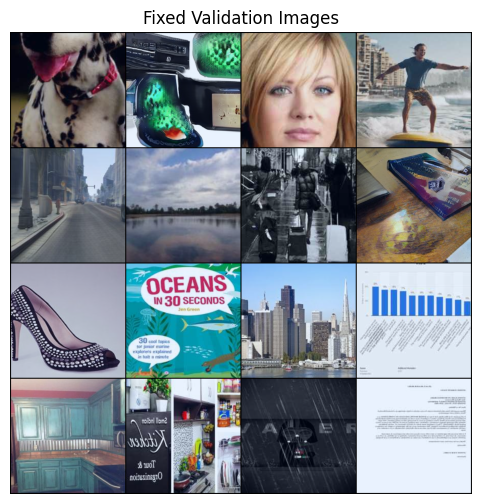

Fake: 011381.png
Fake: 023060.png
Fake: 011602.png
Fake: 019152.png
Fake: 022325.png
Fake: 000202.png
Fake: 033271.png
Fake: 016295.png
Real: 0004182.png
Real: 0007278.png
Real: 0024165.png
Real: 0014296.png
Real: 0000187.png
Real: 0016618.png
Real: 0004252.png
Real: 0008935.png


In [13]:
# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)

grid_size = 4
num_images = grid_size * grid_size

if isinstance(val_dataset, torch.utils.data.Subset):
    subset = val_dataset
    base = val_dataset.dataset

    all_indices = subset.indices
    all_paths  = [base.samples[i][0] for i in all_indices]
    all_labels = [base.samples[i][1] for i in all_indices]

else:
    all_paths  = [p for p, l in val_dataset.samples]
    all_labels = [l for p, l in val_dataset.samples]

labels_tensor = torch.tensor(all_labels)

real_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]
fake_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]

half_num = num_images // 2
real_sample = real_indices[torch.randperm(len(real_indices))[:half_num]]
fake_sample = fake_indices[torch.randperm(len(fake_indices))[:half_num]]

subset_indices = torch.cat([real_sample, fake_sample])

if isinstance(val_dataset, torch.utils.data.Subset):
    base = val_dataset.dataset
    original_indices = [all_indices[i.item()] for i in subset_indices]

    fixed_images = torch.stack([base[i][0] for i in original_indices]).to(device)
    fixed_labels = torch.tensor([base[i][1] for i in original_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

else:
    fixed_images = torch.stack([val_dataset[i][0] for i in subset_indices]).to(device)
    fixed_labels = torch.tensor([val_dataset[i][1] for i in subset_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

grid_img = make_grid(fixed_images.cpu(), nrow=grid_size, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_img.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Fixed Validation Images")
plt.show()

for path, lbl in zip(fixed_paths, fixed_labels):
    print(f"{'Real' if lbl==0 else 'Fake'}: {os.path.basename(path)}")


In [14]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_pbar = tqdm(train_loader, desc="Training", unit="batch")
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
        train_acc = 100.0 * correct / total

        train_pbar.set_postfix({
            "Loss": f"{avg_loss:.4f}",
            "Train Acc": f"{train_acc:.2f}%"
        })

    avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
    train_acc = 100.0 * correct / total if total > 0 else 0.0
    return avg_loss, train_acc


def eval_accuracy(model, loader, device, desc="Evaluating"):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, unit="batch", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100.0 * correct / total if total > 0 else 0.0
    return acc


In [ ]:
def sliding_window_training(
    model,
    criterion,
    optimizer,
    train_dataset,
    val_dataset,
    train_real_indices,
    train_fake_indices_by_w,
    val_real_indices,
    val_fake_indices_by_w,
    max_w,
    num_epochs_per_step,
    batch_size,
    device,
    model_name="Temporal_ResNet50",
    num_workers=0,
    csv_name_used = None
):
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if csv_name_used is None:
        csv_name_used = "none provided"

    params = {
        "model": model_name,
        "dataset split used:": csv_name_used,
        "max_w": max_w,
        "epochs_per_step": num_epochs_per_step,
        "batch_size": batch_size,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }

    log_txt, log_json_path, json_log = create_run_logger(
        model_name=model_name,
        params=params,
        timestamp=timestamp
    )

    # Log device + dataset sizes
    device_info = str(device)
    if device.type == "cuda":
        device_info += f" ({torch.cuda.get_device_name(0)})"
        print(f"Using device: {device_info}")
    else:
        device_info += " (CPU)"
        print(f"Using device: {device_info}")

    with open(log_txt, "a") as f:
        f.write(f"Using device: {device_info}\n")
        f.write(f"Using dataset: {csv_name_used}\n")
        f.write(f"Using model: {model_name }\n")
        f.write(f"Using max sliding window: {max_w}\n")
        f.write(f"Using epochs per step: {num_epochs_per_step}\n")
        f.write(f"Using batch size: {batch_size}\n")
        f.write(f"Using learning rate: {optimizer.param_groups[0]['lr']}\n")
        f.write(f"Dataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}\n\n")

    history = []
    start_time = time.time()
    best_val_acc = 0

    for k in range(0, max_w):  # last step is k=max_w-1 with next window = max_w
        print("\n" + "="*70)
        print(f" - Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }")
        print("="*70)

        logger_add_step(
            json_log,
            step_index=k,
            windows_used=list(range(0, k+1))
        )

        past_windows = list(range(0, k))
        next_window  = k + 1
        all_up_to_next = list(range(0, max_w+1))

        # Build loaders
        train_loader, n_train = make_loader_for_windows(
            train_dataset,
            train_real_indices,
            train_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers
        )

        val_past_loader, n_val_past = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_next_loader, n_val_next = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            [next_window],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_all_loader, n_val_all = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            all_up_to_next,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        print(f"Train: {n_train} samples (Real + Fake windows {past_windows})")
        print(f"Val past: {n_val_past} samples (windows {past_windows})")
        print(f"Val next: {n_val_next} samples (window {next_window})")
        print(f"Val all: {n_val_all} samples (windows {all_up_to_next})")

        with open(log_txt, "a") as f:
            f.write(f"Step: {k}\n")
            f.write(f" * Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }\n")
            f.write(f"Train: {n_train} samples (Real + Fake windows {past_windows})\n")
            f.write(f"Val past: {n_val_past} samples (windows {past_windows})\n")
            f.write(f"Val next: {n_val_next} samples (window {next_window})\n")
            f.write(f"Val all: {n_val_all} samples (windows {all_up_to_next})\n\n")

        # Train for num_epochs_per_step on current window setup
        for epoch in range(num_epochs_per_step):
            epoch_start_time = time.time()
            print(f"\n[Step {k}] Epoch {epoch+1}/{num_epochs_per_step}")

            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )

            # Three validations
            acc_past = eval_accuracy(model, val_past_loader, device, desc="Val past")
            acc_next = eval_accuracy(model, val_next_loader, device, desc="Val next")
            acc_all = eval_accuracy(model, val_all_loader,  device, desc="Val all")

            print(
                f"[Step {k} | Epoch {epoch+1}] "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                f"ValPast: {acc_past:.2f}% | ValNext: {acc_next:.2f}% | ValAll: {acc_all:.2f}%"
            )

            history.append({
                "step": k,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_past_acc": acc_past,
                "val_next_acc": acc_next,
                "val_all_acc": acc_all
            })
            total_epoch_minutes = (time.time() - epoch_start_time) / 60.0

            logger_add_epoch(
                json_log,
                step_index=k,
                epoch_index=epoch+1,
                metrics={
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_past_acc": acc_past,
                    "val_next_acc": acc_next,
                    "val_all_acc": acc_all,
                    "epoch_minutes": total_epoch_minutes
                }
            )

            with open(log_txt, "a") as f:
                f.write(f"Step: {k} ; Epoch = : {epoch+1}\n")
                f.write(f"\tTrain Loss: {train_loss} ; Train Acc {train_acc}\n")
                f.write(f"\tVal Past Acc: {acc_past}\n")
                f.write(f"\tVal Next Acc: {acc_next}\n")
                f.write(f"\tVal All Acc: {acc_all}\n")
                if epoch+1 == num_epochs_per_step:
                    f.write(f"\tTotal Epoch Minutes {total_epoch_minutes:.2f}\n\n")
                    f.write(f"{'='*30}\n")
                else:
                    f.write(f"\tTotal Epoch Minutes {total_epoch_minutes:.2f}\n")

            if acc_all > best_val_acc:
                best_val_acc = acc_all
                torch.save(model.state_dict(), f"best_{model_name}_{timestamp}.pth")

            save_json_log(json_log, log_json_path)

            print(f"Total Epoch time: {total_epoch_minutes:.2f} minutes")

    total_minutes = (time.time() - start_time) / 60.0
    print(f"\nSliding-window training complete in {total_minutes:.2f} minutes.")

    with open(log_txt, "a") as f:
        f.write(f"Best Validation accuracy for all windows: {best_val_acc}")
        f.write(f"Training Complete in: {total_minutes:.2f} minutes.")

    return history

## Training

In [ ]:
num_epochs_per_step = 1

history = sliding_window_training(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_real_indices=train_real_indices,
    train_fake_indices_by_w=train_fake_indices_by_w,
    val_real_indices=val_real_indices,
    val_fake_indices_by_w=val_fake_indices_by_w,
    max_w=max_w,
    num_epochs_per_step=num_epochs_per_step,
    batch_size=batch_size,
    device=device,
    model_name="Temporal_ResNet50",
    num_workers=0,
    csv_name_used=csv_name
)


Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

 - Sliding step 0: train on w[0..0], validate on w1
Train: 12851 samples (Real + Fake windows [0])
Val past: 3160 samples (windows [0])
Val next: 3161 samples (window 1)
Val all: 5668 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 0] Epoch 1/1


Training: 100%|██████████| 402/402 [02:38<00:00,  2.53batch/s, Loss=0.2278, Train Acc=98.56%]


[Step 0 | Epoch 1] Train Loss: 0.2278 | Train Acc: 98.56% | ValPast: 97.94% | ValNext: 93.36% | ValAll: 67.29%
Total Epoch time: 3.98 minutes

 - Sliding step 1: train on w[0..1], validate on w2
Train: 14169 samples (Real + Fake windows [0, 1])
Val past: 3474 samples (windows [0, 1])
Val next: 3168 samples (window 2)
Val all: 5668 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 1] Epoch 1/1


Training: 100%|██████████| 443/443 [01:46<00:00,  4.14batch/s, Loss=0.2989, Train Acc=94.49%]


[Step 1 | Epoch 1] Train Loss: 0.2989 | Train Acc: 94.49% | ValPast: 93.55% | ValNext: 93.88% | ValAll: 76.62%
Total Epoch time: 3.15 minutes

 - Sliding step 2: train on w[0..2], validate on w3
Train: 15471 samples (Real + Fake windows [0, 1, 2])
Val past: 3795 samples (windows [0, 1, 2])
Val next: 3162 samples (window 3)
Val all: 5668 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 2] Epoch 1/1


...

[Step 5 | Epoch 1] Train Loss: 0.3233 | Train Acc: 92.58% | ValPast: 91.10% | ValNext: 92.98% | ValAll: 82.55%
Total Epoch time: 3.76 minutes

 - Sliding step 6: train on w[0..6], validate on w7
Train: 20515 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6])
Val past: 5028 samples (windows [0, 1, 2, 3, 4, 5, 6])
Val next: 3163 samples (window 7)
Val all: 5668 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 6] Epoch 1/1


Training: 100%|██████████| 642/642 [02:32<00:00,  4.22batch/s, Loss=0.3334, Train Acc=92.26%]


[Step 6 | Epoch 1] Train Loss: 0.3334 | Train Acc: 92.26% | ValPast: 90.23% | ValNext: 86.91% | ValAll: 82.85%
Total Epoch time: 4.10 minutes

 - Sliding step 7: train on w[0..7], validate on w8
Train: 21768 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6, 7])
Val past: 5344 samples (windows [0, 1, 2, 3, 4, 5, 6, 7])
Val next: 3171 samples (window 8)
Val all: 5668 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 7] Epoch 1/1


Training: 100%|██████████| 681/681 [03:19<00:00,  3.42batch/s, Loss=0.3792, Train Acc=88.91%]


[Step 7 | Epoch 1] Train Loss: 0.3792 | Train Acc: 88.91% | ValPast: 88.29% | ValNext: 86.88% | ValAll: 85.83%
Total Epoch time: 5.11 minutes

Sliding-window training complete in 30.84 minutes.


In [ ]:
hist_df = pd.DataFrame(history)
print(hist_df.head())
